# Merge and Export Machine Learning Dataset (regression) — Berlin
This notebook gathers all pre-calculated features (OSM POIs, Land Use, Momepy) and merges them with the **real noise values in dB** into one comprehensive `.csv` table for testing the Barcelona regression models, mirroring `notebooks/_elena/01_create_dataset_regre.ipynb`.

## Note: Data Requirements

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

print("Libraries imported.")

Libraries imported.


## Load the datasets

In [2]:
path_osm_roads    = "data/osm_roads_noise_regre.csv"
path_momepy_roads = "data/momepy_roads_features.csv"
path_osm_points   = "data/osm_points_features.csv"
path_osmlanduse   = "data/osm_landuse_features.csv"

df_osm_roads    = pd.read_csv(path_osm_roads)
df_momepy_roads = pd.read_csv(path_momepy_roads)
df_osm_points   = pd.read_csv(path_osm_points)
df_osm_landuse  = pd.read_csv(path_osmlanduse)

print("Data loaded successfully.")

Data loaded successfully.


In [3]:
df_osm_roads.head()

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,dist_to_main
0,172539_172562_0,53.849999,53.849999,46.000000,3,19406.495889,0.000000,0.0,0.0,130.367348,845.336539,0.0
1,172539_34694336_0,55.025000,55.025000,47.531251,3,19015.019606,435.703514,0.0,0.0,0.000000,867.701362,0.0
2,172539_34694265_0,59.366667,59.366667,49.953333,4,19175.649431,431.894550,0.0,0.0,0.000000,867.701362,0.0
3,172545_271370539_0,65.300003,65.300003,56.900002,4,18944.230854,800.614365,0.0,0.0,101.228333,996.552367,0.0
4,172545_34694336_0,57.033333,57.033333,48.916667,3,18957.026756,800.614365,0.0,0.0,0.000000,996.552367,0.0


In [4]:
# Drop dist_to_main (Berlin-specific feature not in the Barcelona schema) for strict parity
if 'dist_to_main' in df_osm_roads.columns:
    df_osm_roads = df_osm_roads.drop(columns=['dist_to_main'])
    print("Dropped dist_to_main for schema parity with Barcelona")
df_osm_roads.head()

Dropped dist_to_main for schema parity with Barcelona


,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,172539_172562_0,53.849999,53.849999,46.000000,3,19406.495889,0.000000,0.0,0.0,130.367348,845.336539
1,172539_34694336_0,55.025000,55.025000,47.531251,3,19015.019606,435.703514,0.0,0.0,0.000000,867.701362
2,172539_34694265_0,59.366667,59.366667,49.953333,4,19175.649431,431.894550,0.0,0.0,0.000000,867.701362
3,172545_271370539_0,65.300003,65.300003,56.900002,4,18944.230854,800.614365,0.0,0.0,101.228333,996.552367
4,172545_34694336_0,57.033333,57.033333,48.916667,3,18957.026756,800.614365,0.0,0.0,0.000000,996.552367


In [5]:
df_momepy_roads.head()

,road_id,width,openness,betweenness,closeness_global,closeness_400,straightness
0,172539_172562_0,28.940821,0.728070,0.004091,0.000069,2.819245e-06,0.852416
1,172539_34694336_0,43.648847,0.924419,0.000911,0.000069,6.748056e-07,0.837846
2,172539_34694265_0,37.132640,0.797297,0.003291,0.000069,7.868624e-07,0.842749
3,172545_271370539_0,50.000000,1.000000,0.000005,0.000069,1.828302e-06,0.833956
4,172545_34694336_0,49.244843,0.933333,0.000774,0.000068,1.431952e-06,0.832365


In [6]:
# Drop non-ML columns from momepy (openness is a morphological intermediate)
df_momepy_roads.drop(['openness'], axis=1, inplace=True)
df_momepy_roads.head()

,road_id,width,betweenness,closeness_global,closeness_400,straightness
0,172539_172562_0,28.940821,0.004091,0.000069,2.819245e-06,0.852416
1,172539_34694336_0,43.648847,0.000911,0.000069,6.748056e-07,0.837846
2,172539_34694265_0,37.132640,0.003291,0.000069,7.868624e-07,0.842749
3,172545_271370539_0,50.000000,0.000005,0.000069,1.828302e-06,0.833956
4,172545_34694336_0,49.244843,0.000774,0.000068,1.431952e-06,0.832365


In [7]:
df_osm_points.head()

,road_id,signals,transport,pois
0,172539_172562_0,0.027463,0.009154,0.002289
1,172539_34694336_0,0.007274,0.002910,0.000000
2,172539_34694265_0,0.020748,0.008299,0.000000
3,172545_271370539_0,0.050295,0.026704,0.000000
4,172545_34694336_0,0.050295,0.019385,0.000000


In [8]:
df_osm_landuse.head()

,road_id,green,industrial,commercial
0,172539_172562_0,46.818402,0.0,5.098466
1,172539_34694336_0,50.593614,0.0,0.000000
2,172539_34694265_0,14.723614,0.0,0.000000
3,172545_271370539_0,19.276736,0.0,0.000000
4,172545_34694336_0,8.047110,0.0,0.000000


## Merge dataframes

In [9]:
def merge_feature_dataframe(base_df, feature_df, cols_to_drop):
    clean_df = feature_df.drop(columns=[c for c in cols_to_drop if c in feature_df.columns], errors='ignore')
    cols_to_remove = [c for c in clean_df.columns if c in base_df.columns and c != 'road_id']
    clean_df = clean_df.drop(columns=cols_to_remove, errors='ignore')
    if 'road_id' not in clean_df.columns or 'road_id' not in base_df.columns:
        return base_df
    clean_df['road_id'] = clean_df['road_id'].astype(str)
    base_df = base_df.copy()
    base_df['road_id'] = base_df['road_id'].astype(str)
    return base_df.merge(clean_df, on='road_id', how='left')

In [10]:
ml_dataset = df_osm_roads.copy()
cols_to_drop = ['noise_day', 'noise_evening', 'noise_night']

print("Road ID types:")
print(f"ml_dataset: {ml_dataset['road_id'].dtype}")

for name, df in [
    ('OSM Points',   df_osm_points),
    ('Momepy Roads', df_momepy_roads),
    ('OSM Landuse',  df_osm_landuse),
]:
    if 'road_id' in df.columns:
        print(f"{name}: {df['road_id'].dtype}")
    else:
        print(f"{name}: NO road_id column!")
    ml_dataset = merge_feature_dataframe(ml_dataset, df, cols_to_drop)

ml_dataset = ml_dataset.fillna(0)

display(ml_dataset.head(10))
ml_dataset.info()
print(f"Final dataset shape: {ml_dataset.shape}")

Road ID types:
ml_dataset: str
OSM Points: str
Momepy Roads: str
OSM Landuse: str


,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,...,transport,pois,width,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
0,172539_172562_0,53.849999,53.849999,46.000000,3,19406.495889,0.000000,0.000000,0.000000,130.367348,...,0.009154,0.002289,28.940821,0.004091,0.000069,2.819245e-06,0.852416,46.818402,0.0,5.098466
1,172539_34694336_0,55.025000,55.025000,47.531251,3,19015.019606,435.703514,0.000000,0.000000,0.000000,...,0.002910,0.000000,43.648847,0.000911,0.000069,6.748056e-07,0.837846,50.593614,0.0,0.000000
2,172539_34694265_0,59.366667,59.366667,49.953333,4,19175.649431,431.894550,0.000000,0.000000,0.000000,...,0.008299,0.000000,37.132640,0.003291,0.000069,7.868624e-07,0.842749,14.723614,0.0,0.000000
3,172545_271370539_0,65.300003,65.300003,56.900002,4,18944.230854,800.614365,0.000000,0.000000,101.228333,...,0.026704,0.000000,50.000000,0.000005,0.000069,1.828302e-06,0.833956,19.276736,0.0,0.000000
4,172545_34694336_0,57.033333,57.033333,48.916667,3,18957.026756,800.614365,0.000000,0.000000,0.000000,...,0.019385,0.000000,49.244843,0.000774,0.000068,1.431952e-06,0.832365,8.047110,0.0,0.000000
5,172545_28345515_0,55.442857,55.442857,46.728571,4,18957.026756,631.324162,0.000000,0.000000,0.000000,...,0.023285,0.005821,42.807543,0.000553,0.000068,1.429051e-06,0.831858,4.821879,0.0,0.000000
6,172546_28345850_0,68.400002,68.400002,59.900002,3,18724.937644,654.325566,0.000000,314.318263,44.752758,...,0.026704,0.019155,34.813549,0.000725,0.000070,3.896279e-06,0.845276,7.309701,0.0,0.000000
7,172546_530313_0,67.420001,67.420001,58.280000,3,18707.192874,609.420663,0.000000,364.880692,0.000000,...,0.022137,0.000000,29.568842,0.001027,0.000070,3.542744e-06,0.845222,1.660445,0.0,0.000000
8,172547_28346151_0,46.933333,46.933333,38.500000,5,19076.030136,433.299111,245.062216,0.000000,0.000000,...,0.009248,0.000000,37.841945,0.000383,0.000070,9.999323e-07,0.839340,14.958962,0.0,0.000000
9,172547_172549_0,57.927778,57.927778,48.933333,4,18888.999084,531.979259,245.062216,0.000000,0.000000,...,0.012553,0.000000,37.714311,0.003367,0.000070,1.128043e-06,0.840653,1.158002,0.0,0.000000


<class 'pandas.DataFrame'>
RangeIndex: 70890 entries, 0 to 70889
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                70890 non-null  str    
 1   noise_day              70890 non-null  float64
 2   noise_evening          70890 non-null  float64
 3   noise_night            70890 non-null  float64
 4   road_category          70890 non-null  int64  
 5   dist_to_trunk          70890 non-null  float64
 6   dist_to_primary        70890 non-null  float64
 7   dist_to_secondary      70890 non-null  float64
 8   dist_to_tertiary       70890 non-null  float64
 9   dist_to_residential    70890 non-null  float64
 10  dist_to_living_street  70890 non-null  float64
 11  signals                70890 non-null  float64
 12  transport              70890 non-null  float64
 13  pois                   70890 non-null  float64
 14  width                  70890 non-null  float64
 15  betweenness  

## Noise distribution

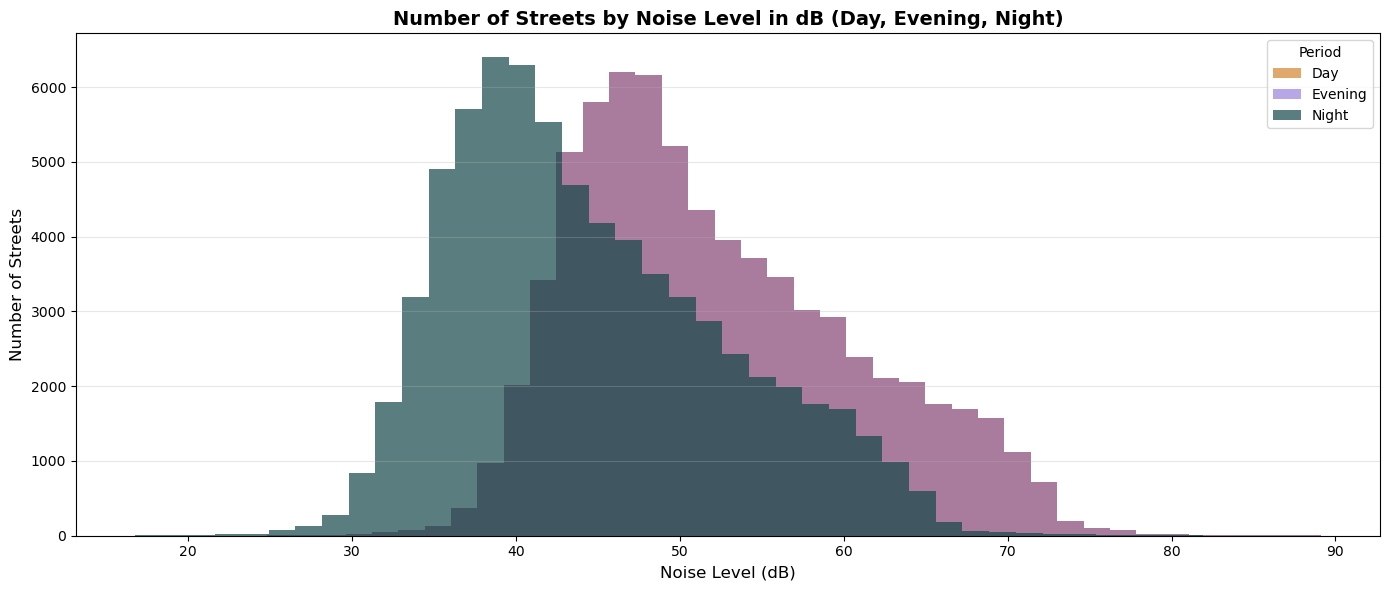

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.hist(ml_dataset['noise_day'], bins=40, color='#d58430', alpha=0.7, label='Day')
ax.hist(ml_dataset['noise_evening'], bins=40, color='#7251ce', alpha=0.5, label='Evening')
ax.hist(ml_dataset['noise_night'], bins=40, color='#144849', alpha=0.7, label='Night')
ax.set_title('Number of Streets by Noise Level in dB (Day, Evening, Night)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')
plt.tight_layout()
plt.show()

## Export to CSV
Final master table for testing the Barcelona regression models.

In [12]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "ber_noise_regre_ml_dataset.csv")
ml_dataset.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\ber_noise_regre_ml_dataset.csv


## Subsample
Stratified subsample preserving the noise_day distribution. The dB values can be continuous, so the stratification uses 5-dB bins (Barcelona's exact-value stratification would put every street in its own stratum).

In [13]:
sample_size = min(5000, len(ml_dataset))

bins = (ml_dataset['noise_day'] // 5 * 5).astype(int)
proportions = bins.value_counts(normalize=True).sort_index()
samples_per_value = (proportions * sample_size).round().astype(int)

subsampled = pd.concat([
    ml_dataset[bins == val].sample(n=min(n, int((bins == val).sum())), random_state=42, replace=False)
    for val, n in samples_per_value.items() if n > 0
])

subsampled = subsampled.sample(frac=1, random_state=42).reset_index(drop=True)

print((subsampled['noise_day'] // 5 * 5).astype(int).value_counts(normalize=True).sort_index())

noise_day
25    0.000400
30    0.002400
35    0.030994
40    0.183563
45    0.261748
50    0.181364
55    0.139172
60    0.096781
65    0.072386
70    0.027794
75    0.002599
80    0.000600
85    0.000200
Name: proportion, dtype: float64


## Before and after sampling

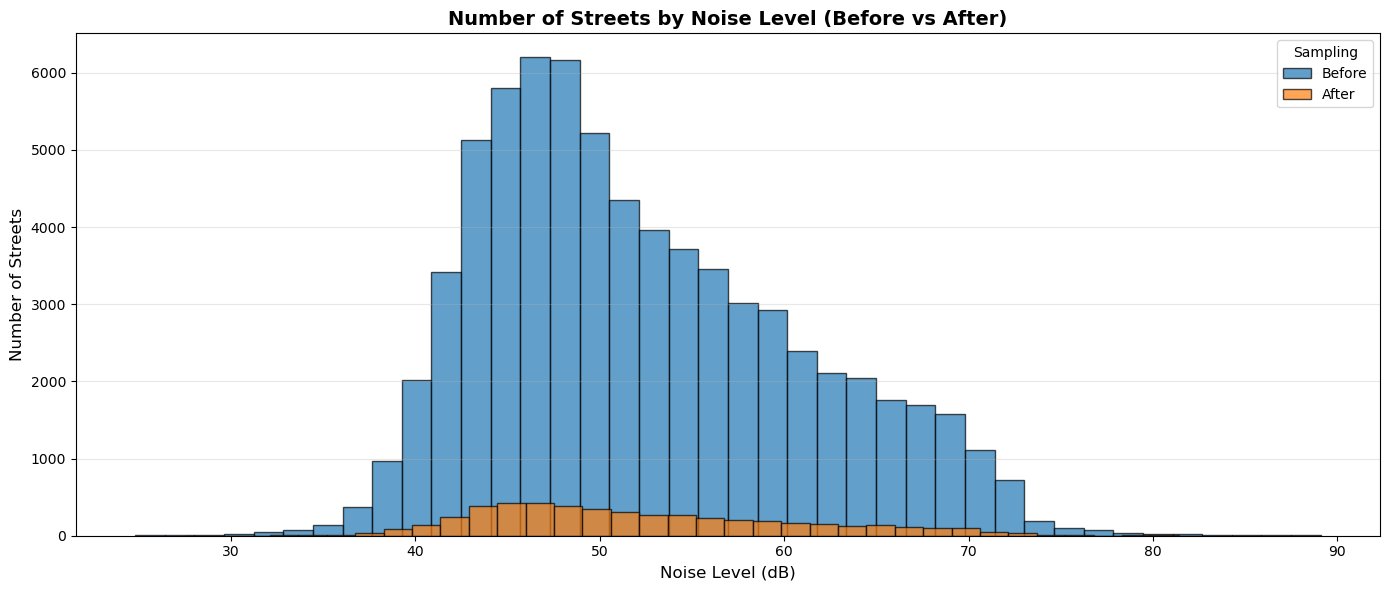

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.hist(ml_dataset['noise_day'], bins=40, alpha=0.7, label='Before', edgecolor='black')
ax.hist(subsampled['noise_day'], bins=40, alpha=0.7, label='After', edgecolor='black')
ax.set_title('Number of Streets by Noise Level (Before vs After)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Sampling')
plt.tight_layout()
plt.show()

## Export CSV

In [15]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "ber_noise_regre_ml_subsample.csv")
subsampled.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\ber_noise_regre_ml_subsample.csv


## Schema check vs Barcelona
The columns must match `bcn_noise_regre_ml_dataset.csv` exactly (names and order) so the pickled scaler/models apply directly.

In [16]:
bcn = pd.read_csv("../../../notebooks/_elena/data/bcn_noise_regre_ml_dataset.csv", nrows=5)

print("Columns match Barcelona schema:", list(ml_dataset.columns) == list(bcn.columns))
print("NaN values:", ml_dataset.isna().sum().sum())
print("Duplicated road_id:", ml_dataset['road_id'].duplicated().sum())
assert list(ml_dataset.columns) == list(bcn.columns), "schema mismatch with Barcelona"
print("Schema parity with Barcelona confirmed.")

Columns match Barcelona schema: True
NaN values: 0
Duplicated road_id: 0
Schema parity with Barcelona confirmed.
